# Stage 4 — Causal Forest for heterogeneous advertising effects

**Business question:** if only a fraction of eligible users can receive an ad, can we rank users by the incremental probability of a visit caused by treatment—not merely by their probability of visiting?

This notebook fits an honest CausalForestDML model, evaluates it only on a randomized holdout, and compares it with the Stage 3 T-Learner and a conventional response model under the same training budget.

The estimand is the conditional average treatment effect (CATE):

$$\tau(x)=E[Y(1)-Y(0)\mid X=x].$$

Here treatment is randomized ad assignment and the primary outcome is visit. Therefore subgroup treated-minus-control differences on the untouched test set have a causal interpretation under the experiment assumptions.

## 1. Why a causal forest?

A T-Learner estimates two response surfaces and subtracts them. A causal forest instead builds trees around treatment-effect heterogeneity. EconML's CausalForestDML first residualizes the outcome and treatment with cross-fitted nuisance models, then fits an honest forest to the residualized causal signal.

- **Cross-fitting** limits overfitting bias in nuisance predictions.
- **Honesty** uses separate observations to choose splits and estimate leaf effects.
- **Many trees** average unstable partitions.
- **BLB inference** provides uncertainty estimates for forest effects.

Random assignment makes the propensity known and essentially constant. We therefore use a constant-prior treatment model instead of asking a flexible model to learn random noise. The outcome nuisance model remains flexible.

Important: a forest prediction is a local average effect estimate, not an observed individual treatment effect. Only one potential outcome is ever observed for each user.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import econml
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn import __version__ as sklearn_version
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='X does not have valid feature names.*')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python       :', platform.python_version())
print('Executable   :', Path(sys.executable).name)
print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('scikit-learn:', sklearn_version)
print('LightGBM     :', lgb.__version__)
print('EconML       :', econml.__version__)

Python       : 3.10.19
Executable   : python
NumPy        : 2.2.6
pandas       : 2.3.2
scikit-learn: 1.7.1
LightGBM     : 4.6.0
EconML       : 0.17.0


## 2. Reproduce the same sample and split

The full file is about 14 million rows. To keep the notebook laptop-friendly, we reproduce the fixed approximately one-million-row Bernoulli sample used in earlier stages, then make the same 60/20/20 stratified train/validation/test split. The test set is not used for model selection.

For a fair and practical benchmark, all three models in this notebook use the same 400,000-row stratified subset of the training split. The original validation and test sets remain unchanged.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'
FEATURES = [f'f{i}' for i in range(12)]
TARGET = 'visit'
KEEP_COLS = FEATURES + ['treatment', 'visit', 'conversion']
DTYPES = {
    **{c: 'float32' for c in FEATURES},
    'treatment': 'int8',
    'visit': 'int8',
    'conversion': 'int8',
}

EXPECTED_ROWS = 13_979_592
SAMPLE_TARGET = 1_000_000
CHUNK_SIZE = 500_000
RANDOM_SEED = 42
sample_probability = SAMPLE_TARGET / EXPECTED_ROWS

start = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)
parts = []
rows_scanned = 0
for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, dtype=DTYPES, chunksize=CHUNK_SIZE):
    rows_scanned += len(chunk)
    keep = rng.random(len(chunk)) < sample_probability
    parts.append(chunk.loc[keep].copy())

df = pd.concat(parts, ignore_index=True)
elapsed = time.perf_counter() - start
print(f'Scanned {rows_scanned:,} rows in {elapsed:.1f} seconds.')
print(f'Modeling sample: {len(df):,} rows; memory {df.memory_usage(deep=True).sum()/1024**2:.1f} MiB.')

Scanned 13,979,592 rows in 12.5 seconds.
Modeling sample: 999,453 rows; memory 48.6 MiB.


In [3]:
strata = df['treatment'].astype(str) + '_' + df[TARGET].astype(str)
train_df, temp_df = train_test_split(
    df, test_size=0.40, random_state=RANDOM_SEED, stratify=strata
)
temp_strata = temp_df['treatment'].astype(str) + '_' + temp_df[TARGET].astype(str)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_strata
)

train_strata = train_df['treatment'].astype(str) + '_' + train_df[TARGET].astype(str)
forest_train, _ = train_test_split(
    train_df, train_size=400_000, random_state=RANDOM_SEED + 10, stratify=train_strata
)

split_summary = pd.concat({
    name: frame.groupby('treatment')[TARGET].agg(['size', 'sum', 'mean'])
    for name, frame in [
        ('forest_train', forest_train), ('validation', valid_df), ('test', test_df)
    ]
}, names=['split', 'treatment'])
display(split_summary)

assert not set(['treatment', 'exposure', 'visit', 'conversion']).intersection(FEATURES)
assert forest_train.index.intersection(test_df.index).empty
assert valid_df.index.intersection(test_df.index).empty
print('Leakage, split, and disjoint-holdout checks passed.')

size    sum     mean
split        treatment                        
forest_train 0           59831   2219 0.037088
             1          340169  16529 0.048591
validation   0           29899   1109 0.037092
             1          169992   8260 0.048591
test         0           29900   1109 0.037090
             1          169991   8260 0.048591

Leakage, split, and disjoint-holdout checks passed.


## 3. Fit CausalForestDML

The treatment is binary and randomized. The primary outcome is binary. We use two-fold cross-fitting for nuisance estimation, 200 honest trees, relatively large leaves for stability, and inference enabled.

Hyperparameters are deliberately conservative rather than extensively tuned on this one experiment. A production workflow would tune only on training/validation data, record runtime and sensitivity, and preserve a final untouched evaluation set.

In [4]:
def make_lgbm(seed: int, n_estimators: int = 180) -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        objective='binary',
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=200,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )

X_cf = forest_train[FEATURES].to_numpy(dtype=np.float32)
y_cf = forest_train[TARGET].to_numpy(dtype=np.int8)
t_cf = forest_train['treatment'].to_numpy(dtype=np.int8)
X_test_np = test_df[FEATURES].to_numpy(dtype=np.float32)
y_test = test_df[TARGET].to_numpy(dtype=np.int8)
t_test = test_df['treatment'].to_numpy(dtype=np.int8)

causal_forest = CausalForestDML(
    model_y=make_lgbm(RANDOM_SEED + 20),
    model_t=DummyClassifier(strategy='prior'),
    discrete_outcome=True,
    discrete_treatment=True,
    categories=[0, 1],
    cv=2,
    n_estimators=200,
    criterion='mse',
    max_depth=15,
    min_samples_leaf=200,
    max_samples=0.45,
    honest=True,
    inference=True,
    subforest_size=4,
    n_jobs=-1,
    random_state=RANDOM_SEED + 20,
)

start = time.perf_counter()
causal_forest.fit(y_cf, t_cf, X=X_cf, inference='auto')
forest_fit_seconds = time.perf_counter() - start
cf_cate = np.asarray(causal_forest.effect(X_test_np)).reshape(-1)

print(f'Causal forest fit time: {forest_fit_seconds:.1f} seconds')
print(f'Generated {len(cf_cate):,} out-of-sample CATE predictions.')

Causal forest fit time: 44.4 seconds
Generated 199,891 out-of-sample CATE predictions.


## 4. Fair benchmark models

We refit the Stage 3 T-Learner and a conventional response model on exactly the same 400,000 training rows. The validation set controls LightGBM early stopping; the test set is still untouched.

- T-Learner score: predicted visit under treatment minus predicted visit under control.
- Response score: predicted visit probability regardless of treatment.
- Causal forest score: estimated conditional incremental effect.

The response model answers who will visit; the causal models try to answer whose visit probability changes because of the ad.

In [5]:
treated_train = forest_train['treatment'].eq(1)
control_train = forest_train['treatment'].eq(0)
treated_valid = valid_df['treatment'].eq(1)
control_valid = valid_df['treatment'].eq(0)

model_treated = make_lgbm(RANDOM_SEED + 31, n_estimators=600)
model_control = make_lgbm(RANDOM_SEED + 32, n_estimators=600)
response_model = make_lgbm(RANDOM_SEED + 33, n_estimators=600)

fit_specs = [
    ('Treated outcome model', model_treated, treated_train, treated_valid),
    ('Control outcome model', model_control, control_train, control_valid),
    ('Pooled response model', response_model,
     pd.Series(True, index=forest_train.index), pd.Series(True, index=valid_df.index)),
]
fit_records = []
for name, model, train_mask, valid_mask in fit_specs:
    start = time.perf_counter()
    model.fit(
        forest_train.loc[train_mask, FEATURES],
        forest_train.loc[train_mask, TARGET],
        eval_set=[(valid_df.loc[valid_mask, FEATURES], valid_df.loc[valid_mask, TARGET])],
        eval_metric='binary_logloss',
        callbacks=[lgb.early_stopping(40, verbose=False)],
    )
    fit_records.append({
        'model': name,
        'train_rows': int(train_mask.sum()),
        'best_iteration': model.best_iteration_,
        'fit_seconds': time.perf_counter() - start,
    })

p1 = model_treated.predict_proba(test_df[FEATURES])[:, 1]
p0 = model_control.predict_proba(test_df[FEATURES])[:, 1]
t_cate = p1 - p0
response_score = response_model.predict_proba(test_df[FEATURES])[:, 1]
display(pd.DataFrame(fit_records).set_index('model'))

,train_rows,best_iteration,fit_seconds
model,,,
Treated outcome model,340169,126,1.554455
Control outcome model,59831,83,0.655758
Pooled response model,400000,140,1.801829


## 5. Aggregate calibration and CATE distribution

Before celebrating heterogeneity, check that average predicted effects are in the neighborhood of the experiment's overall intent-to-treat effect. A good ranking may still be miscalibrated in level, so this is a diagnostic rather than a pass/fail theorem.

,effect,ci_95_low,ci_95_high
estimate,,,
Randomized test difference-in-means,0.011501,0.009127,0.013874
Causal forest ATE over test X,0.006740,-0.009017,0.022496
Mean causal-forest CATE,0.006740,NaN,NaN
Mean T-Learner CATE,0.007474,NaN,NaN


,Causal Forest,T-Learner
count,"199,891.000000","199,891.000000"
mean,0.006740,0.007474
std,0.018990,0.033557
min,-0.041736,-0.258828
1%,-0.010190,-0.059633
10%,-0.000655,-0.001580
25%,0.000266,-0.000265
50%,0.000725,-0.000061
75%,0.004985,0.002713
90%,0.016825,0.022218


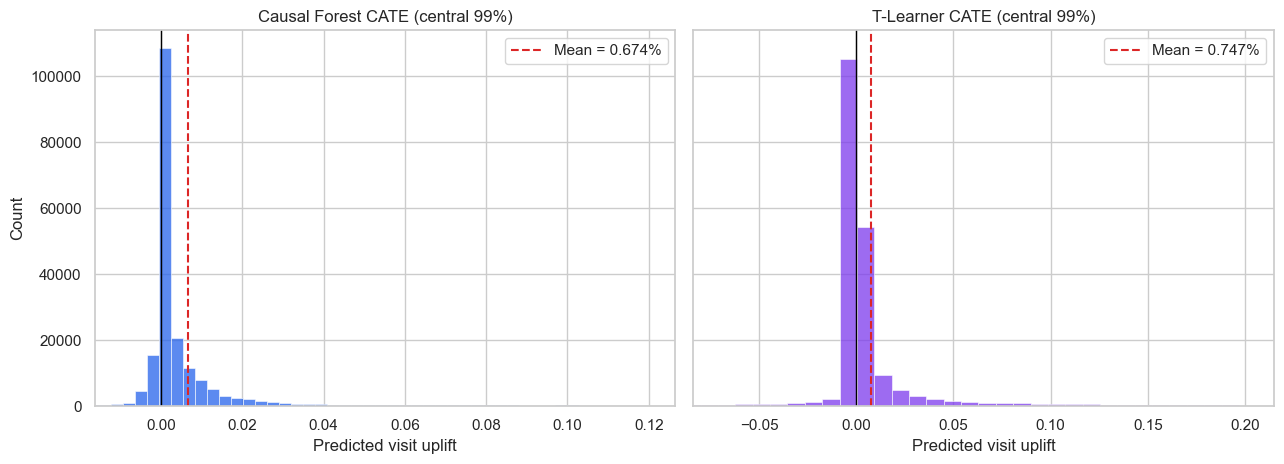

In [6]:
def difference_in_means(y, t):
    yt, yc = y[t == 1], y[t == 0]
    effect = yt.mean() - yc.mean()
    se = np.sqrt(yt.mean() * (1 - yt.mean()) / len(yt) + yc.mean() * (1 - yc.mean()) / len(yc))
    return effect, effect - 1.96 * se, effect + 1.96 * se

test_ate, test_ate_low, test_ate_high = difference_in_means(y_test, t_test)
cf_ate = float(np.asarray(causal_forest.ate(X_test_np)).squeeze())
cf_ate_low, cf_ate_high = causal_forest.ate_interval(X_test_np, alpha=0.05)
cf_ate_low = float(np.asarray(cf_ate_low).squeeze())
cf_ate_high = float(np.asarray(cf_ate_high).squeeze())

aggregate = pd.DataFrame([
    {'estimate': 'Randomized test difference-in-means', 'effect': test_ate, 'ci_95_low': test_ate_low, 'ci_95_high': test_ate_high},
    {'estimate': 'Causal forest ATE over test X', 'effect': cf_ate, 'ci_95_low': cf_ate_low, 'ci_95_high': cf_ate_high},
    {'estimate': 'Mean causal-forest CATE', 'effect': cf_cate.mean(), 'ci_95_low': np.nan, 'ci_95_high': np.nan},
    {'estimate': 'Mean T-Learner CATE', 'effect': t_cate.mean(), 'ci_95_low': np.nan, 'ci_95_high': np.nan},
]).set_index('estimate')
display(aggregate)

distribution = pd.DataFrame({
    'Causal Forest': pd.Series(cf_cate).describe(percentiles=[.01, .10, .25, .50, .75, .90, .99]),
    'T-Learner': pd.Series(t_cate).describe(percentiles=[.01, .10, .25, .50, .75, .90, .99]),
})
display(distribution)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, score, name, color in [
    (axes[0], cf_cate, 'Causal Forest', '#2563eb'),
    (axes[1], t_cate, 'T-Learner', '#7c3aed'),
]:
    q_low, q_high = np.quantile(score, [0.005, 0.995])
    sns.histplot(score, bins=75, ax=ax, color=color)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(score.mean(), color='#dc2626', linestyle='--', label=f'Mean = {score.mean():.3%}')
    ax.set(xlim=(q_low, q_high), title=f'{name} CATE (central 99%)', xlabel='Predicted visit uplift')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Forest uncertainty: pointwise BLB intervals

We compute forest intervals on a fixed 5,000-user test subset to keep the notebook responsive. These are pointwise intervals conditional on the fitted procedure—not simultaneous guarantees across every user, and not a license to claim an individual causal effect. Checking whether an interval excludes zero after selecting a user for an extreme point prediction also creates selection bias.

,value
users,"5,000.000000"
median_interval_width,0.006932
mean_interval_width,0.017335
share_interval_entirely_positive,0.184600
share_interval_entirely_negative,0.002600
point_estimate_sd,0.017028


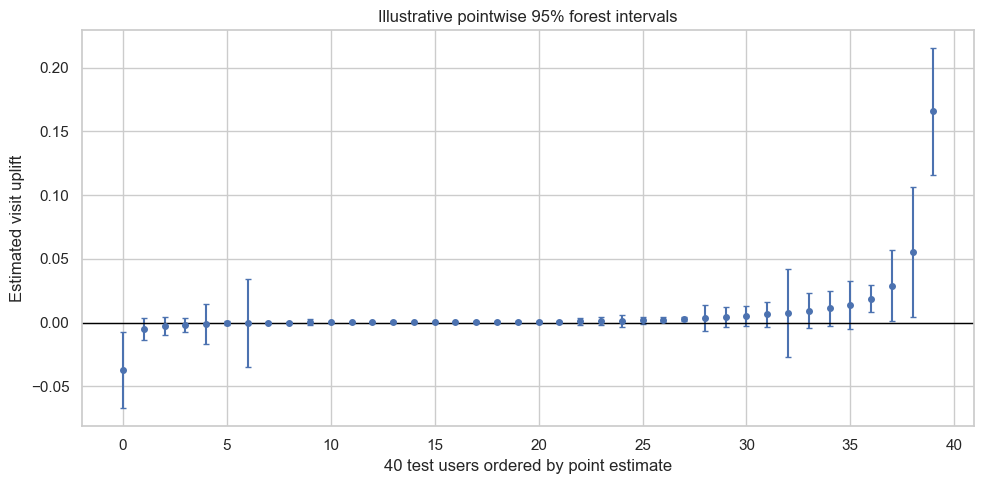

In [7]:
interval_rng = np.random.default_rng(RANDOM_SEED + 40)
interval_idx = np.sort(interval_rng.choice(len(test_df), size=5_000, replace=False))
interval_point = cf_cate[interval_idx]
interval_low, interval_high = causal_forest.effect_interval(X_test_np[interval_idx], alpha=0.05)
interval_low = np.asarray(interval_low).reshape(-1)
interval_high = np.asarray(interval_high).reshape(-1)

interval_summary = pd.Series({
    'users': len(interval_idx),
    'median_interval_width': np.median(interval_high - interval_low),
    'mean_interval_width': np.mean(interval_high - interval_low),
    'share_interval_entirely_positive': np.mean(interval_low > 0),
    'share_interval_entirely_negative': np.mean(interval_high < 0),
    'point_estimate_sd': np.std(interval_point),
}, name='value')
display(interval_summary.to_frame())

show_idx = np.argsort(interval_point)[np.linspace(0, len(interval_point)-1, 40).astype(int)]
order = np.argsort(interval_point[show_idx])
points = interval_point[show_idx][order]
low = interval_low[show_idx][order]
high = interval_high[show_idx][order]
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(np.arange(len(points)), points, yerr=np.vstack([points-low, high-points]), fmt='o', ms=4, capsize=2)
ax.axhline(0, color='black', linewidth=1)
ax.set(title='Illustrative pointwise 95% forest intervals', xlabel='40 test users ordered by point estimate', ylabel='Estimated visit uplift')
plt.tight_layout()
plt.show()

## 7. GATES: does the ranking reproduce in randomized data?

Users are sorted by each model's test-set score and divided into equal-sized deciles. Within every decile we ignore the model prediction and estimate uplift directly as treated visit rate minus control visit rate. This group-average treatment-effect check is much more defensible than trying to validate unobservable user-level effects.

A useful ranker should generally place higher observed uplift in higher-score groups, although sampling noise means perfect monotonicity is not expected.

,model,decile,users,mean_score,observed_uplift,ci_95_low,ci_95_high
9,Causal Forest,10,19989,0.051010,0.076400,0.060117,0.092684
8,Causal Forest,9,19989,0.010957,0.011375,0.000921,0.021829
7,Causal Forest,8,19989,0.005112,-0.001985,-0.009421,0.005450
6,Causal Forest,7,19989,0.002427,-0.004470,-0.009450,0.000511
5,Causal Forest,6,19989,0.001089,-0.000882,-0.004252,0.002488
4,Causal Forest,5,19989,0.000579,0.000730,-0.000742,0.002201
3,Causal Forest,4,19989,0.000393,0.000689,-0.000615,0.001992
2,Causal Forest,3,19989,0.000263,-0.000219,-0.001928,0.001490
1,Causal Forest,2,19989,-0.000118,-0.001707,-0.004904,0.001491
0,Causal Forest,1,19990,-0.004314,0.007983,-0.000852,0.016818


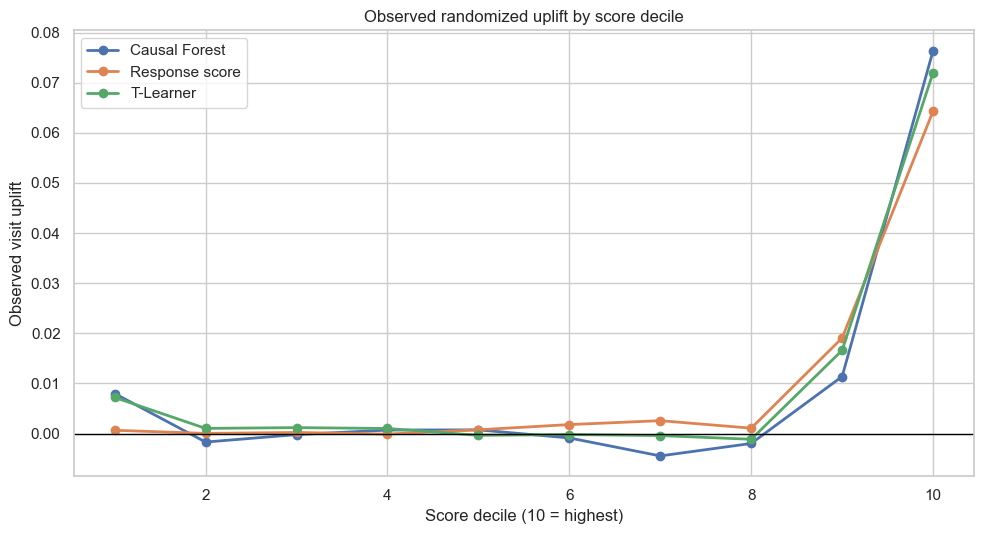

In [8]:
def uplift_by_decile(score, model_name):
    labels = pd.qcut(pd.Series(score).rank(method='first'), q=10, labels=range(1, 11)).astype(int).to_numpy()
    rows = []
    for decile in range(1, 11):
        mask = labels == decile
        effect, low, high = difference_in_means(y_test[mask], t_test[mask])
        rows.append({
            'model': model_name,
            'decile': decile,
            'users': int(mask.sum()),
            'mean_score': np.mean(np.asarray(score)[mask]),
            'observed_uplift': effect,
            'ci_95_low': low,
            'ci_95_high': high,
        })
    return pd.DataFrame(rows)

gates = pd.concat([
    uplift_by_decile(cf_cate, 'Causal Forest'),
    uplift_by_decile(t_cate, 'T-Learner'),
    uplift_by_decile(response_score, 'Response score'),
], ignore_index=True)
display(gates.loc[gates['model'].eq('Causal Forest')].sort_values('decile', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
for name, frame in gates.groupby('model'):
    ax.plot(frame['decile'], frame['observed_uplift'], marker='o', linewidth=2, label=name)
ax.axhline(0, color='black', linewidth=1)
ax.set(title='Observed randomized uplift by score decile', xlabel='Score decile (10 = highest)', ylabel='Observed visit uplift')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Policy value at realistic budget constraints

For a policy targeting fraction q, we estimate incremental visits per 1,000 eligible users as:

$$1000\times q\times(\bar Y_{T=1,S=1}-\bar Y_{T=0,S=1}).$$

Because assignment was randomized, the within-selected-audience difference estimates the effect of treating that selected audience. It is then multiplied by audience share to put every policy on the same eligible-population scale.

The comparison is offline policy evaluation. It assumes the experiment's treatment is the policy action and that there is no interference, hidden delivery mismatch, or deployment drift.

In [9]:
def top_mask(score, fraction):
    order = np.argsort(-np.asarray(score), kind='stable')
    selected_n = int(round(fraction * len(order)))
    mask = np.zeros(len(order), dtype=bool)
    mask[order[:selected_n]] = True
    return mask

def evaluate_policy(name, score, fraction):
    selected = top_mask(score, fraction)
    effect, low, high = difference_in_means(y_test[selected], t_test[selected])
    q = selected.mean()
    return {
        'budget': fraction,
        'policy': name,
        'selected_users': int(selected.sum()),
        'subgroup_uplift': effect,
        'uplift_ci_95_low': low,
        'uplift_ci_95_high': high,
        'value_per_1k': 1000 * q * effect,
        'value_ci_95_low_per_1k': 1000 * q * low,
        'value_ci_95_high_per_1k': 1000 * q * high,
    }

policy_rows = []
for fraction in [0.10, 0.30]:
    policy_rows.extend([
        evaluate_policy('Causal Forest', cf_cate, fraction),
        evaluate_policy('T-Learner', t_cate, fraction),
        evaluate_policy('Response score', response_score, fraction),
        {
            'budget': fraction, 'policy': 'Random targeting',
            'selected_users': int(round(fraction * len(test_df))),
            'subgroup_uplift': test_ate,
            'uplift_ci_95_low': test_ate_low,
            'uplift_ci_95_high': test_ate_high,
            'value_per_1k': 1000 * fraction * test_ate,
            'value_ci_95_low_per_1k': 1000 * fraction * test_ate_low,
            'value_ci_95_high_per_1k': 1000 * fraction * test_ate_high,
        },
    ])
policy_table = pd.DataFrame(policy_rows).set_index(['budget', 'policy']).sort_index()
display(policy_table)

selected_users  subgroup_uplift  uplift_ci_95_low  \
budget   policy                                                                
0.100000 Causal Forest              19989         0.076400          0.060117   
         Random targeting           19989         0.011501          0.009127   
         Response score             19989         0.064321          0.045706   
         T-Learner                  19989         0.072039          0.055828   
0.300000 Causal Forest              59967         0.033543          0.026663   
         Random targeting           59967         0.011501          0.009127   
         Response score             59967         0.033360          0.025832   
         T-Learner                  59967         0.033082          0.026663   

                           uplift_ci_95_high  value_per_1k  \
budget   policy                                              
0.100000 Causal Forest              0.092684      7.640004   
         Random targeting           0.013874      1.150051   
         Response score             0.082936      6.432095   
         T-Learner                  0.088250      7.203875   
0.300000 Causal Forest              0.040423     10.062964   
         Random targeting           0.013874      3.450152   
         Response score             0.040887     10.007862   
         T-Learner                  0.039501      9.924653   

                           value_ci_95_low_per_1k  value_ci_95_high_per_1k  
budget   policy                                                             
0.100000 Causal Forest                   6.011682                 9.268326  
         Random targeting                0.912703                 1.387399  
         Response score                  4.570593                 8.293596  
         T-Learner                       5.582817                 8.824933  
0.300000 Causal Forest                   7.998993                12.126936  
         Random targeting                2.738108                 4.162196  
         Response score                  7.749547                12.266176  
         T-Learner                       7.998994                11.850312

## 9. Paired bootstrap comparison

Point estimates alone can overstate small model differences. We resample the same test users for both policies so each bootstrap draw preserves their pairing. The intervals below measure holdout sampling uncertainty conditional on the fitted models and fixed audience cutoffs; they do not include model-retraining uncertainty.

In [10]:
def value_for_mask(mask, indexes):
    chosen = mask[indexes]
    sample_t = t_test[indexes][chosen]
    sample_y = y_test[indexes][chosen]
    q = chosen.mean()
    return 1000 * q * (sample_y[sample_t == 1].mean() - sample_y[sample_t == 0].mean())

bootstrap_rng = np.random.default_rng(RANDOM_SEED + 100)
n_bootstrap = 200
bootstrap_rows = []
all_indexes = np.arange(len(test_df))
for fraction in [0.10, 0.30]:
    masks = {
        'Causal Forest': top_mask(cf_cate, fraction),
        'T-Learner': top_mask(t_cate, fraction),
        'Response score': top_mask(response_score, fraction),
    }
    for competitor in ['T-Learner', 'Response score']:
        point = value_for_mask(masks['Causal Forest'], all_indexes) - value_for_mask(masks[competitor], all_indexes)
        draws = np.empty(n_bootstrap)
        for b in range(n_bootstrap):
            indexes = bootstrap_rng.integers(0, len(test_df), size=len(test_df))
            draws[b] = value_for_mask(masks['Causal Forest'], indexes) - value_for_mask(masks[competitor], indexes)
        bootstrap_rows.append({
            'budget': fraction,
            'comparison': f'Causal Forest minus {competitor}',
            'point_difference_per_1k': point,
            'bootstrap_mean_per_1k': draws.mean(),
            'ci_95_low': np.quantile(draws, 0.025),
            'ci_95_high': np.quantile(draws, 0.975),
            'draws': n_bootstrap,
        })

bootstrap_table = pd.DataFrame(bootstrap_rows).set_index(['budget', 'comparison'])
display(bootstrap_table)

point_difference_per_1k  \
budget   comparison                                                    
0.100000 Causal Forest minus T-Learner                      0.436129   
         Causal Forest minus Response score                 1.207909   
0.300000 Causal Forest minus T-Learner                      0.138312   
         Causal Forest minus Response score                 0.055103   

                                             bootstrap_mean_per_1k  ci_95_low  \
budget   comparison                                                             
0.100000 Causal Forest minus T-Learner                    0.435791  -0.680961   
         Causal Forest minus Response score               1.119534  -0.426199   
0.300000 Causal Forest minus T-Learner                    0.114328  -1.133668   
         Causal Forest minus Response score               0.025667  -1.106662   

                                             ci_95_high  draws  
budget   comparison                                             
0.100000 Causal Forest minus T-Learner         1.490239    200  
         Causal Forest minus Response score    2.668339    200  
0.300000 Causal Forest minus T-Learner         1.208781    200  
         Causal Forest minus Response score    1.190121    200

## 10. Policy-value curves and area above random

A single budget can hide ranking behavior elsewhere. The curve evaluates cumulative policy value from 1% to 100% targeting. Random targeting has expected value q times the test ATE.

We report the trapezoidal area under this policy-value curve and subtract ATE divided by two, the area under the random line. This is a Qini-style summary with an explicitly stated normalization; uplift libraries use several incompatible definitions, so always define the formula.

,value_at_10pct_per_1k,value_at_30pct_per_1k,AUUC_x1000,area_above_random_x1000
ranking,,,,
Causal Forest,7.640004,10.062964,9.843644,4.093391
T-Learner,7.203875,9.924653,9.651567,3.901313
Response score,6.432095,10.007862,9.997710,4.247456


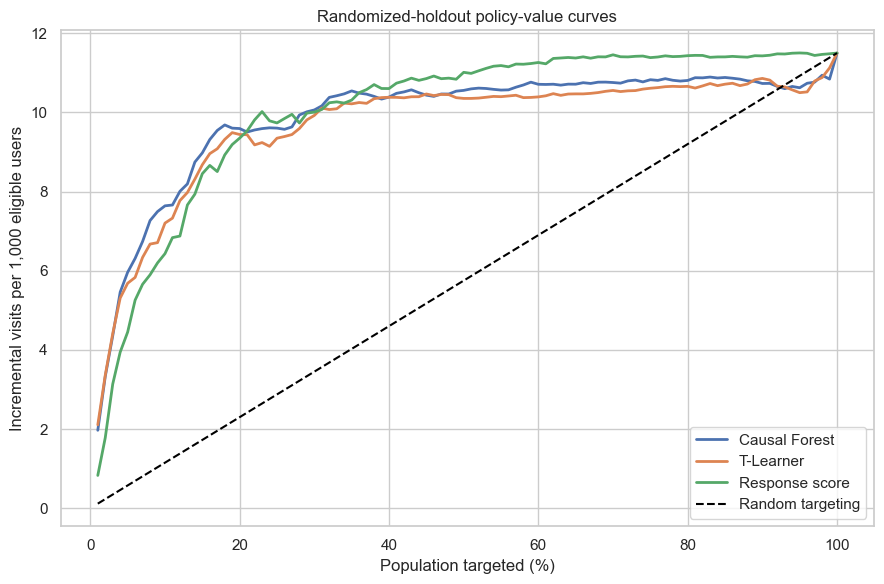

In [11]:
def policy_curve(score, fractions):
    order = np.argsort(-np.asarray(score), kind='stable')
    sorted_t = t_test[order]
    sorted_y = y_test[order]
    cumulative_t_n = np.cumsum(sorted_t)
    cumulative_c_n = np.cumsum(1 - sorted_t)
    cumulative_t_y = np.cumsum(sorted_t * sorted_y)
    cumulative_c_y = np.cumsum((1 - sorted_t) * sorted_y)
    treated_rate = np.divide(cumulative_t_y, cumulative_t_n, out=np.full(len(order), np.nan), where=cumulative_t_n > 0)
    control_rate = np.divide(cumulative_c_y, cumulative_c_n, out=np.full(len(order), np.nan), where=cumulative_c_n > 0)
    cumulative_value = (np.arange(len(order)) + 1) / len(order) * (treated_rate - control_rate)
    indexes = np.maximum(1, (fractions * len(order)).astype(int)) - 1
    return cumulative_value[indexes]

fractions = np.linspace(0.01, 1.0, 100)
score_map = {'Causal Forest': cf_cate, 'T-Learner': t_cate, 'Response score': response_score}
curves = {name: policy_curve(score, fractions) for name, score in score_map.items()}
curve_rows = []
q_grid = np.r_[0, fractions]
for name, values in curves.items():
    auuc = np.trapezoid(np.r_[0, values], q_grid)
    curve_rows.append({
        'ranking': name,
        'value_at_10pct_per_1k': 1000 * values[9],
        'value_at_30pct_per_1k': 1000 * values[29],
        'AUUC_x1000': 1000 * auuc,
        'area_above_random_x1000': 1000 * (auuc - test_ate / 2),
    })
curve_metrics = pd.DataFrame(curve_rows).set_index('ranking')
display(curve_metrics)

fig, ax = plt.subplots(figsize=(9, 6))
for name, values in curves.items():
    ax.plot(100 * fractions, 1000 * values, linewidth=2, label=name)
ax.plot(100 * fractions, 1000 * fractions * test_ate, '--', color='black', label='Random targeting')
ax.set(title='Randomized-holdout policy-value curves', xlabel='Population targeted (%)', ylabel='Incremental visits per 1,000 eligible users')
ax.legend()
plt.tight_layout()
plt.show()

## 11. What heterogeneity is the forest using?

Forest feature importance describes which variables are used for heterogeneity splits. It is not response-prediction importance, not a causal effect of the feature, and not proof that changing the feature changes ad effectiveness. Correlated and anonymized variables make interpretation especially limited.

,heterogeneity_importance
f6,0.303215
f3,0.289663
f8,0.181541
f9,0.161157
f2,0.025820
f0,0.021413
f10,0.008782
f7,0.006188
f4,0.001217
f11,0.000382


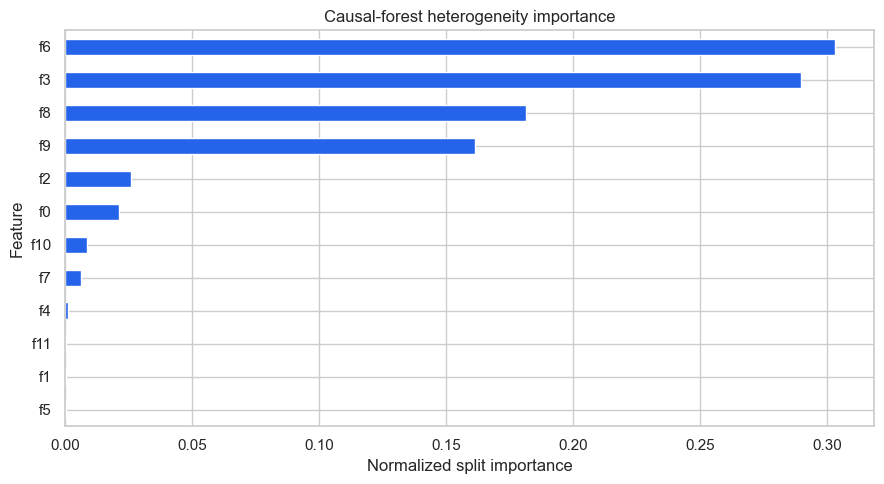

,spearman_score_correlation,share_of_CF_top30_in_both,jaccard_top30
comparison,,,
Causal Forest vs T-Learner,0.657059,0.830857,0.710655
Causal Forest vs Response score,0.589233,0.800790,0.667765


In [12]:
importance = pd.Series(causal_forest.feature_importances_, index=FEATURES, name='heterogeneity_importance').sort_values(ascending=False)
display(importance.to_frame())

fig, ax = plt.subplots(figsize=(9, 5))
importance.sort_values().plot.barh(ax=ax, color='#2563eb')
ax.set(title='Causal-forest heterogeneity importance', xlabel='Normalized split importance', ylabel='Feature')
plt.tight_layout()
plt.show()

top30 = {name: top_mask(score, 0.30) for name, score in score_map.items()}
overlap_rows = []
for competitor in ['T-Learner', 'Response score']:
    intersection = top30['Causal Forest'] & top30[competitor]
    union = top30['Causal Forest'] | top30[competitor]
    overlap_rows.append({
        'comparison': f'Causal Forest vs {competitor}',
        'spearman_score_correlation': stats.spearmanr(score_map['Causal Forest'], score_map[competitor]).statistic,
        'share_of_CF_top30_in_both': intersection.sum() / top30['Causal Forest'].sum(),
        'jaccard_top30': intersection.sum() / union.sum(),
    })
overlap_table = pd.DataFrame(overlap_rows).set_index('comparison')
display(overlap_table)

## 12. Automatically generated readout

This cell turns the executed results into a concise interpretation. It deliberately distinguishes point estimates from statistically supported conclusions.

In [13]:
cf_gates = gates.loc[gates['model'].eq('Causal Forest')].set_index('decile')
cf_top = cf_gates.loc[10]
cf_bottom = cf_gates.loc[1]
rank_corr = stats.spearmanr(cf_gates.index, cf_gates['observed_uplift']).statistic
cf10 = policy_table.loc[(0.10, 'Causal Forest')]
tl10 = policy_table.loc[(0.10, 'T-Learner')]
rs10 = policy_table.loc[(0.10, 'Response score')]
rnd10 = policy_table.loc[(0.10, 'Random targeting')]
cf30 = policy_table.loc[(0.30, 'Causal Forest')]
tl30 = policy_table.loc[(0.30, 'T-Learner')]
rs30 = policy_table.loc[(0.30, 'Response score')]
rnd30 = policy_table.loc[(0.30, 'Random targeting')]
bt_t10 = bootstrap_table.loc[(0.10, 'Causal Forest minus T-Learner')]
bt_r10 = bootstrap_table.loc[(0.10, 'Causal Forest minus Response score')]
bt_t30 = bootstrap_table.loc[(0.30, 'Causal Forest minus T-Learner')]
bt_r30 = bootstrap_table.loc[(0.30, 'Causal Forest minus Response score')]

display(Markdown(f'''### Main findings

- The randomized test ATE is **{test_ate:.3%}** (95% CI **{test_ate_low:.3%} to {test_ate_high:.3%}**). The forest's average effect over test covariates is **{cf_ate:.3%}** (forest interval **{cf_ate_low:.3%} to {cf_ate_high:.3%}**). The design-based difference-in-means remains the preferred ATE estimate; the gap is evidence that forest CATE levels are not perfectly calibrated even if the ranking is useful.
- The causal-forest CATE has standard deviation **{cf_cate.std():.3%}**; **{np.mean(cf_cate > 0):.1%}** of point predictions are positive. On the 5,000-user inference sample, the median 95% interval width is **{np.median(interval_high-interval_low):.3%}** and only **{np.mean(interval_low > 0):.1%}** of intervals are entirely positive. This is a useful antidote to overconfident individual targeting stories.
- Forest decile 10 has observed randomized uplift **{cf_top.observed_uplift:.3%}** (95% CI **{cf_top.ci_95_low:.3%} to {cf_top.ci_95_high:.3%}**); decile 1 has **{cf_bottom.observed_uplift:.3%}** (95% CI **{cf_bottom.ci_95_low:.3%} to {cf_bottom.ci_95_high:.3%}**). Decile rank versus observed uplift correlation is only **{rank_corr:.3f}**: the forest isolates a strong top group, but the full ordering is not smoothly monotone.
- At a 10% budget, values per 1,000 eligible users are: forest **{cf10.value_per_1k:.2f}**, T-Learner **{tl10.value_per_1k:.2f}**, response **{rs10.value_per_1k:.2f}**, random **{rnd10.value_per_1k:.2f}**.
- At a 30% budget, values are: forest **{cf30.value_per_1k:.2f}**, T-Learner **{tl30.value_per_1k:.2f}**, response **{rs30.value_per_1k:.2f}**, random **{rnd30.value_per_1k:.2f}**.
- Paired bootstrap, forest minus T-Learner: 10% **{bt_t10.point_difference_per_1k:+.2f}** (95% CI **{bt_t10.ci_95_low:+.2f} to {bt_t10.ci_95_high:+.2f}**); 30% **{bt_t30.point_difference_per_1k:+.2f}** (95% CI **{bt_t30.ci_95_low:+.2f} to {bt_t30.ci_95_high:+.2f}**).
- Paired bootstrap, forest minus response: 10% **{bt_r10.point_difference_per_1k:+.2f}** (95% CI **{bt_r10.ci_95_low:+.2f} to {bt_r10.ci_95_high:+.2f}**); 30% **{bt_r30.point_difference_per_1k:+.2f}** (95% CI **{bt_r30.ci_95_low:+.2f} to {bt_r30.ci_95_high:+.2f}**).
- Across all budgets, area above random is **{curve_metrics.loc['Causal Forest', 'area_above_random_x1000']:.2f}** for the forest, **{curve_metrics.loc['T-Learner', 'area_above_random_x1000']:.2f}** for the T-Learner, and **{curve_metrics.loc['Response score', 'area_above_random_x1000']:.2f}** for response ranking. The response model's slight lead on this integrated metric is a reminder that causal sophistication does not guarantee empirical dominance at every budget.

A model can have attractive point estimates without a statistically conclusive edge over another model. The deployment claim should follow the paired uncertainty, not just the leaderboard order.
'''))

### Main findings

- The randomized test ATE is **1.150%** (95% CI **0.913% to 1.387%**). The forest's average effect over test covariates is **0.674%** (forest interval **-0.902% to 2.250%**). The design-based difference-in-means remains the preferred ATE estimate; the gap is evidence that forest CATE levels are not perfectly calibrated even if the ranking is useful.
- The causal-forest CATE has standard deviation **1.899%**; **84.0%** of point predictions are positive. On the 5,000-user inference sample, the median 95% interval width is **0.693%** and only **18.5%** of intervals are entirely positive. This is a useful antidote to overconfident individual targeting stories.
- Forest decile 10 has observed randomized uplift **7.640%** (95% CI **6.012% to 9.268%**); decile 1 has **0.798%** (95% CI **-0.085% to 1.682%**). Decile rank versus observed uplift correlation is only **0.164**: the forest isolates a strong top group, but the full ordering is not smoothly monotone.
- At a 10% budget, values per 1,000 eligible users are: forest **7.64**, T-Learner **7.20**, response **6.43**, random **1.15**.
- At a 30% budget, values are: forest **10.06**, T-Learner **9.92**, response **10.01**, random **3.45**.
- Paired bootstrap, forest minus T-Learner: 10% **+0.44** (95% CI **-0.68 to +1.49**); 30% **+0.14** (95% CI **-1.13 to +1.21**).
- Paired bootstrap, forest minus response: 10% **+1.21** (95% CI **-0.43 to +2.67**); 30% **+0.06** (95% CI **-1.11 to +1.19**).
- Across all budgets, area above random is **4.09** for the forest, **3.90** for the T-Learner, and **4.25** for response ranking. The response model's slight lead on this integrated metric is a reminder that causal sophistication does not guarantee empirical dominance at every budget.

A model can have attractive point estimates without a statistically conclusive edge over another model. The deployment claim should follow the paired uncertainty, not just the leaderboard order.


## 13. Methodological discussion

- ROC-AUC evaluates outcome prediction rather than the contrast between potential outcomes, so it is not used to select an uplift model.
- Treatment was randomized, so the propensity model is intentionally constant. A flexible treatment model would primarily fit chance imbalance.
- Honest forest construction separates split selection from leaf effect estimation, reducing adaptive bias at the cost of higher variance from using less data per tree.
- Individual effect intervals remain wide because counterfactual outcomes are unobserved, visits are relatively rare, and local estimates use fewer comparable observations. Segment and policy effects are therefore the main decision units.
- Forest feature importance identifies variables used for effect splits; it does not establish that those variables cause treatment responsiveness.

### Limitations

1. The estimand is intent-to-treat because the data records assignment rather than guaranteed exposure.
2. Anonymized features limit product interpretation and actionable segmentation.
3. Results from one experiment may not transport to another campaign, creative, auction environment, or time period.
4. The 400k fitting subset is a compute choice; sensitivity to sample size and forest settings remains useful future work.
5. The paired bootstrap conditions on fitted models and cutoffs; repeated fitting or a nested bootstrap is needed for full-pipeline uncertainty.
6. Post-hoc subgroup searches require multiplicity control and independent confirmation.

The next stage converts the ranking into a budget-aware policy, incorporates unit economics, and specifies a prospective randomized policy test.